# Likelihood localization: debugging one experiment

Runs the likelihood localization of `../Localization/LikelyHoodLocalization.py` (Python version of `LikelyHoodLocalization.m`, no MATLAB needed) for **one** experiment folder, printing and plotting every intermediate state: inputs, circle radii, the circle and likelihood images per tag, and the estimates, confidence and promotions of every round.

Inputs are prepared as in `localization_lkhd.ipynb`. Set the experiment and distance source in the next cell.

In [23]:
import itertools
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial import ConvexHull

LOC_DIR = Path("../Localization").resolve()
sys.path.insert(0, str(LOC_DIR))
from LikelyHoodLocalization import Params, likelihood_localization

EXP = "6"            # experiment folder
BAND = "775-995"     # band in distance_estimates.csv
K_COL = "k_est"      # "k_est", "k_gt", or None for ground-truth distances

# Likelihood parameters: same as localization_merged.ipynb
N_ANCHORS = 8
C = 299792458.0
MAIN_FREQ = 915e6
PHASE_MULT = 2
PERIOD = C / (2 * MAIN_FREQ * PHASE_MULT)  # m, distance per step of K
CIRCLES = 5          # circles per anchor: K, K +- 1, K +- 2 (3 = K, K +- 1; 7 adds K +- 3)
SCALE = 3.0          # image pixels per cm
MARGIN = 0.5         # m
ROUNDS = 5           # max rounds (MATLAB: 5)
BLUR_PX = 21         # radius of the disk blur in pixels (MATLAB: fspecial('disk', 15))
CONF_RADIUS_CM = 150  # black-out radius around the peak for the confidence ratio
MAX_LINK = 2     # m, links with an estimated distance (radius) above this are not used
PROMOTE_BY = "conf"  # when the 10% rule promotes no tag: try one, keep it if this improves ("conf", "error" = oracle, or None)

exp = Path(EXP)
print(f"experiment {EXP}, band {BAND}, K = {K_COL or 'ground truth'}, PERIOD = {PERIOD * 100:.2f} cm")

experiment 6, band 775-995, K = k_est, PERIOD = 8.19 cm


## 1. Positions and anchors

anchors (tag numbers): [1, 2, 3, 4, 7, 8, 10, 11]
tags to localize      : [5, 6, 9, 12]


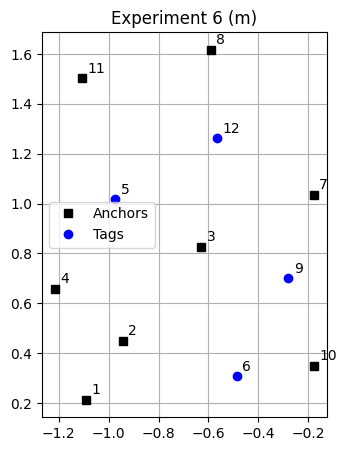

In [24]:
pts = pd.read_csv(exp / "points.csv")[["x", "y"]].to_numpy()
D_gt = np.loadtxt(exp / "distances.csv", delimiter=",", ndmin=2)
anchors = np.array(max(itertools.combinations(range(len(pts)), N_ANCHORS), key=lambda s: ConvexHull(pts[list(s)]).volume))
tags = np.setdiff1d(np.arange(len(pts)), anchors)
print("anchors (tag numbers):", (anchors + 1).tolist())
print("tags to localize      :", (tags + 1).tolist())

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(*pts[anchors].T, "ks", label="Anchors")
ax.plot(*pts[tags].T, "bo", label="Tags")
for i, (x, y) in enumerate(pts):
    ax.annotate(str(i + 1), (x, y), textcoords="offset points", xytext=(4, 4))
ax.set_aspect("equal"); ax.grid(); ax.legend(); ax.set_title(f"Experiment {EXP} (m)")
plt.show()

## 2. Per-run estimates and circle radii
Radius per run = $\frac{c\,\phi}{2\pi f M}$ + K $\cdot$ PERIOD (equals `dist_est_k_svr` when K = `k_est`), then averaged over runs.

In [25]:
est = pd.read_csv(exp / "distance_estimates.csv")
est = est[est["band (MHz)"] == BAND].copy()
if K_COL is not None:
    est["radius"] = C * est["phase_main"] / (2 * np.pi * MAIN_FREQ * PHASE_MULT) + est[K_COL] * PERIOD
else:
    est["radius"] = est["distance"]
is_anchor = set(anchors + 1)
tag_anchor = est[est.tagA_num.isin(is_anchor) ^ est.tagB_num.isin(is_anchor)]  # links between a tag and an anchor
print(f"{len(est)} rows for band {BAND}, {len(tag_anchor)} of them tag-anchor (the only links the method uses at first)")
tag_anchor[["tagA_num", "tagB_num", "run", "distance", "dist_est_svr", "phase_main", "k_est", "k_gt",
            "dist_est_k_svr", "radius"]].round(4)

198 rows for band 775-995, 96 of them tag-anchor (the only links the method uses at first)


,tagA_num,tagB_num,run,distance,dist_est_svr,phase_main,k_est,k_gt,dist_est_k_svr,radius
18,1,5,0,0.8139,0.6878,0.9910,8,10,0.6811,0.6811
19,1,5,1,0.8139,0.6359,0.9934,7,10,0.5993,0.5993
20,1,5,2,0.8139,0.6404,1.0307,7,10,0.6002,0.6002
24,1,6,0,0.6218,0.5747,2.7534,6,7,0.5633,0.5633
25,1,6,1,0.6218,0.5576,2.7532,6,7,0.5632,0.5632
...,...,...,...,...,...,...,...,...,...,...
385,10,12,1,1.0052,0.8704,2.9264,10,11,0.8954,0.8954
386,10,12,2,1.0052,0.8628,2.8997,10,11,0.8947,0.8947
390,11,12,0,0.6044,0.6662,2.6655,7,7,0.6429,0.6429
391,11,12,1,0.6044,0.6480,2.6518,7,7,0.6425,0.6425


In [26]:
radius = est.groupby(["tagA_num", "tagB_num"])["radius"].mean()
R = np.zeros_like(D_gt)
for (a, b), r in radius.items():
    R[a - 1, b - 1] = R[b - 1, a - 1] = r

# Split into whole steps K and the remainder (the circles are drawn at WRAPPED + (K, K +- 1, ...) * PERIOD)
K = np.floor(R / PERIOD)
WRAPPED = R - K * PERIOD

rows = []
for t in tags:
    for a in anchors:
        rows.append({"tag": t + 1, "anchor": a + 1, "true dist (cm)": D_gt[t, a] * 100, "radius (cm)": R[t, a] * 100,
                     "radius err (cm)": (R[t, a] - D_gt[t, a]) * 100, "K": int(K[t, a]),
                     "K true": int(np.floor(D_gt[t, a] / PERIOD)), "wrapped (cm)": WRAPPED[t, a] * 100})
links = pd.DataFrame(rows)
print("Mean |radius err| per tag (cm):", links.groupby("tag")["radius err (cm)"].apply(lambda e: e.abs().mean()).round(1).to_dict())
print("K == K true:", f"{(links.K == links['K true']).mean() * 100:.0f}% of tag-anchor links")
links.round(2)

Mean |radius err| per tag (cm): {5: 14.5, 6: 10.5, 9: 11.2, 12: 8.4}
K == K true: 25% of tag-anchor links


,tag,anchor,true dist (cm),radius (cm),radius err (cm),K,K true,wrapped (cm)
0,5,1,81.39,62.69,-18.70,7,9,5.35
1,5,2,57.02,99.73,42.71,12,6,1.44
2,5,3,40.33,43.63,3.30,5,4,2.67
3,5,4,43.26,39.73,-3.53,4,5,6.96
4,5,7,81.67,70.94,-10.73,8,9,5.41
5,5,8,71.29,89.79,18.50,10,8,7.88
6,5,10,106.47,110.03,3.56,13,12,3.55
7,5,11,50.52,35.17,-15.35,4,6,2.41
8,6,1,62.18,56.34,-5.84,6,7,7.19
9,6,2,49.27,66.34,17.07,8,6,0.82


## 3. Image coordinates
Positions shifted by `MARGIN` and converted to cm; the image is `lim * SCALE` pixels square.

In [27]:
offset = pts.min(axis=0) - MARGIN
P = (pts - offset) * 100  # cm
lim = np.ceil(P.max() + MARGIN * 100)
N_PIX = int(SCALE * lim)
print(f"offset = {offset} m, lim = {lim} cm, image = {N_PIX} x {N_PIX} px")
pd.DataFrame(P, columns=["x (cm)", "y (cm)"], index=pd.Index(np.arange(1, len(P) + 1), name="tag")).round(1)

offset = [-1.716165 -0.28709 ] m, lim = 241.0 cm, image = 723 x 723 px


,x (cm),y (cm)
tag,,
1,62.5,50.0
2,77.2,73.7
3,108.8,111.5
4,50.0,94.6
5,74.1,130.5
6,123.0,59.4
7,153.9,132.2
8,112.5,190.4
9,143.7,98.7


## 4. Localization
`likelihood_localization` from `../Localization/LikelyHoodLocalization.py`:
- Per tag, circles of radius wrapped + K·λ (line width 2) and K ± 1, ... (width 1) around every anchor with a measured link, as in `insertShape`; blurred with a `BLUR_PX` disk; the brightest point is the estimate.
- Confidence = 1 / (max of the normalized image after blacking out `CONF_RADIUS_CM` around the peak).
- After each round the top `floor(n_tags / 10)` tags by confidence become anchors at their estimated positions (as in MATLAB). When that is 0 (fewer than 10 tags left), the most confident tag is tried as an anchor and kept only if the other tags improve: their mean confidence goes up (`PROMOTE_BY = "conf"`), or their mean true error goes down (`"error"`, oracle using ground truth); `None` disables this. Without a promotion the remaining rounds would repeat, so the loop stops.

In [28]:
params = Params(lam=PERIOD * 100, lim=lim, scale=SCALE, circles=CIRCLES, blur_px=BLUR_PX,
                conf_radius=CONF_RADIUS_CM, rounds=ROUNDS, promote_by=PROMOTE_BY)
print(params)
estimates, rounds = likelihood_localization(
    WRAPPED * 100, K, R != 0, anchors, P[anchors], tags, params,
    true_pos=P, labels=list(range(1, len(P) + 1)))
first_round = rounds[0]["states"]

history = pd.DataFrame([
    {"round": r["round"], "tag": t + 1, "est x (cm)": s["est"][0], "est y (cm)": s["est"][1],
     "error (cm)": np.linalg.norm(s["est"] - P[t]), "conf": s["conf"], "n anchors": len(s["anchors_used"]),
     "promoted": t in r["promoted"]}
    for r in rounds for t, s in r["states"].items()])
history.round(2)

Params(lam=8.191050765027322, lim=np.float64(241.0), scale=3.0, circles=5, blur_px=21, conf_radius=150, rounds=5, promote_by='conf')
round 1: 4 tags, 8 anchors, try tag 6: conf score of the other tags 2.372 -> 2.394, promoted, promoted: [6]
round 2: 3 tags, 9 anchors, try tag 5: conf score of the other tags 2.368 -> 2.184, not promoted
no promotion: rounds 3-5 would repeat round 2, stopping


,round,tag,est x (cm),est y (cm),error (cm),conf,n anchors,promoted
0,1,5,70.00,125.67,6.32,2.11,8,False
1,1,6,128.67,73.33,15.08,4.01,8,True
2,1,9,149.67,91.67,9.21,2.17,8,False
3,1,12,127.67,151.67,13.10,2.83,8,False
4,2,5,70.00,125.67,6.32,2.45,9,False
5,2,9,149.00,98.33,5.30,2.40,9,False
6,2,12,127.67,151.67,13.10,2.34,9,False


## 5. Circles and likelihood image per tag (round 1)
Left: raw circle image (before blur). Right: blurred, normalized image. Black squares = anchors, blue circle = true position, red star = estimate; dashed white circle = confidence black-out radius.

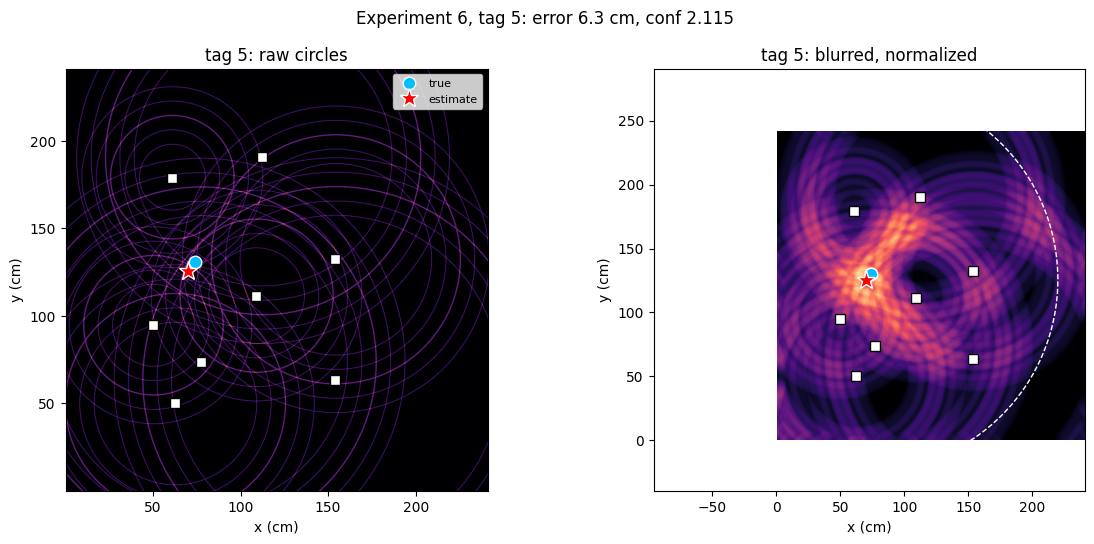

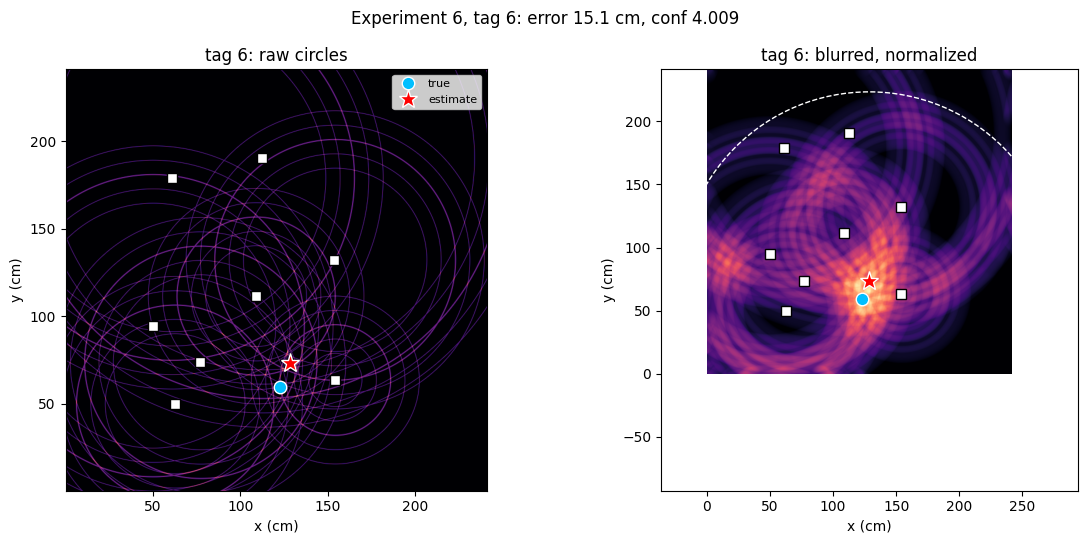

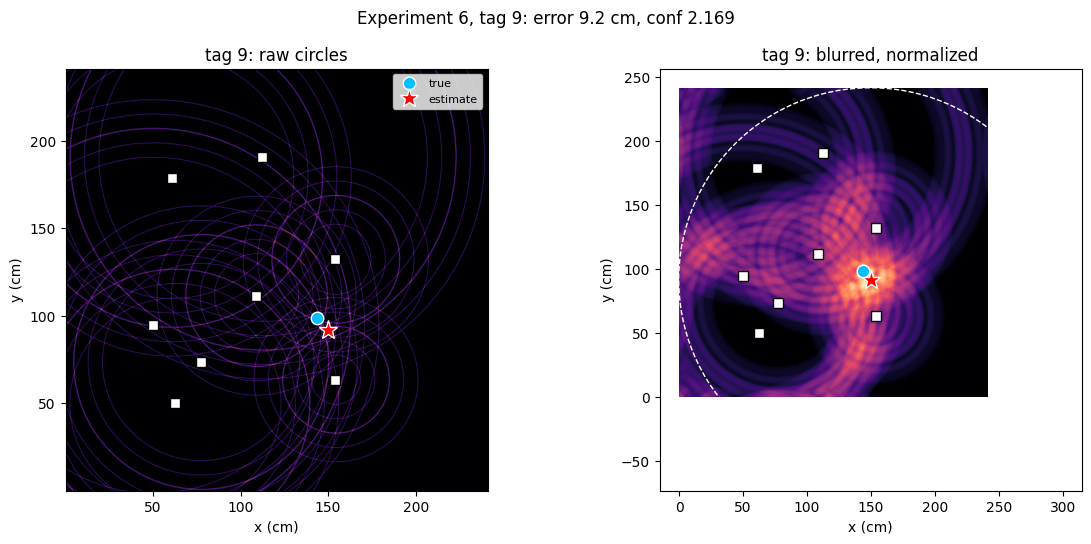

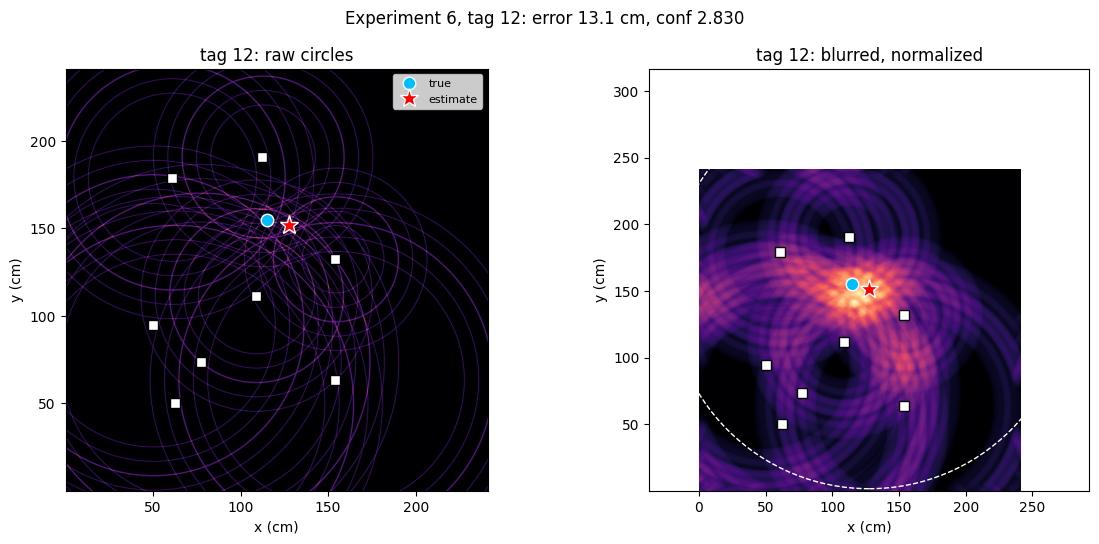

In [29]:
for t, s in first_round.items():
    fig, axs = plt.subplots(1, 2, figsize=(12, 5.5))
    for ax, img, title in [(axs[0], s["raw"], "raw circles"), (axs[1], s["blurred"], "blurred, normalized")]:
        ax.imshow(img, origin="lower", extent=[0.5 / SCALE, (N_PIX + 0.5) / SCALE] * 2, cmap="magma")
        ax.plot(*P[s["anchors_used"]].T, "ws", ms=7, mec="k")
        ax.plot(*P[t], "o", color="deepskyblue", ms=9, mec="w", label="true")
        ax.plot(*s["est"], "r*", ms=14, mec="w", label="estimate")
        ax.set_title(f"tag {t + 1}: {title}"); ax.set_xlabel("x (cm)"); ax.set_ylabel("y (cm)")
    axs[1].add_patch(plt.Circle(s["est"], CONF_RADIUS_CM, fill=False, ls="--", color="w"))
    axs[0].legend(loc="upper right", fontsize=8)
    err = np.linalg.norm(s["est"] - P[t])
    fig.suptitle(f"Experiment {EXP}, tag {t + 1}: error {err:.1f} cm, conf {s['conf']:.3f}")
    plt.tight_layout(); plt.show()

### Zoom around each tag
Same blurred images, ±40 cm around the true position, with the ideal circles (true distances, thin cyan) for comparison.

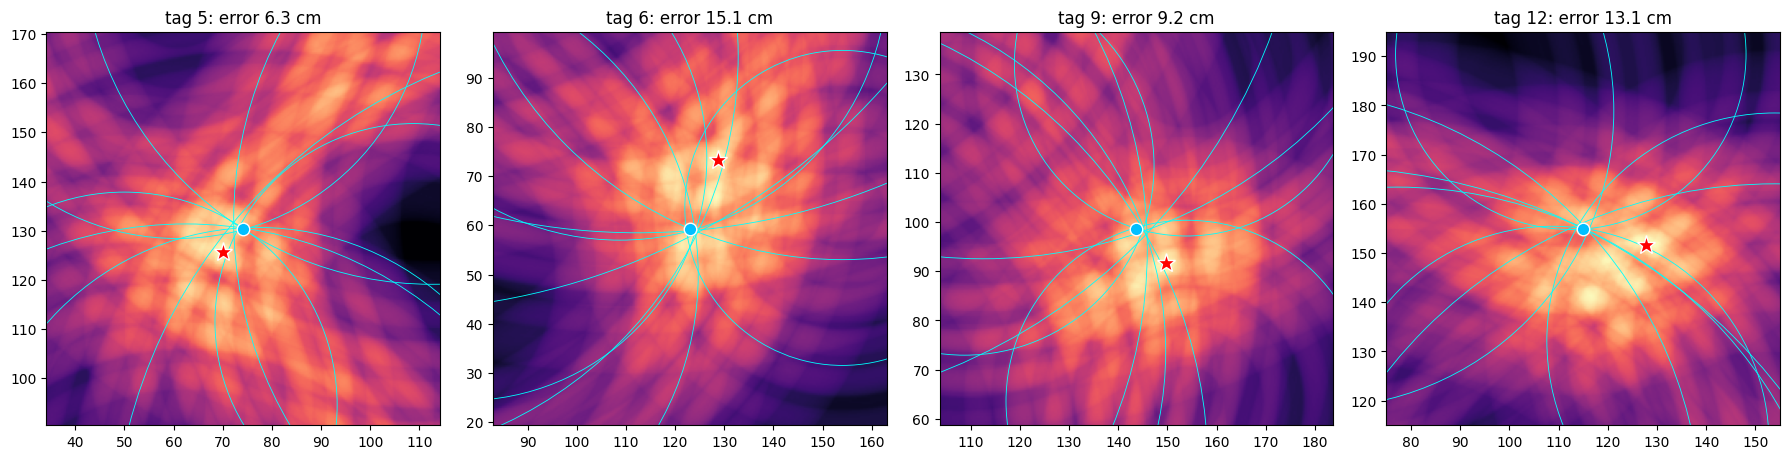

In [30]:
fig, axs = plt.subplots(1, len(first_round), figsize=(4.5 * len(first_round), 4.5), squeeze=False)
for ax, (t, s) in zip(axs[0], first_round.items()):
    ax.imshow(s["blurred"], origin="lower", extent=[0.5 / SCALE, (N_PIX + 0.5) / SCALE] * 2, cmap="magma")
    for a in s["anchors_used"]:
        ax.add_patch(plt.Circle(P[a], D_gt[t, a] * 100, fill=False, color="cyan", lw=0.6))
    ax.plot(*P[t], "o", color="deepskyblue", ms=9, mec="w")
    ax.plot(*s["est"], "r*", ms=14, mec="w")
    ax.set_xlim(P[t][0] - 40, P[t][0] + 40); ax.set_ylim(P[t][1] - 40, P[t][1] + 40)
    ax.set_title(f"tag {t + 1}: error {np.linalg.norm(s['est'] - P[t]):.1f} cm")
plt.tight_layout(); plt.show()

## 6. Result
Final estimate of every tag (from the round it was promoted in, or the last round).

 tag  error (cm)
   5         6.3
   6        15.1
   9         5.3
  12        13.1
mean 10.0 cm


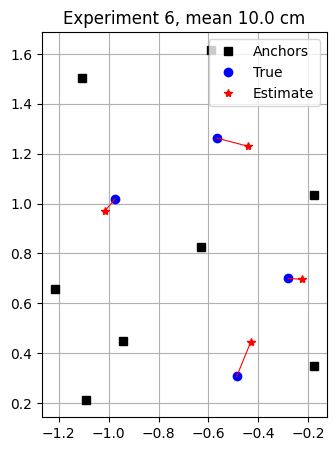

In [31]:
est_m = np.array([estimates[t] for t in tags]) / 100 + offset  # m, original coordinates
err = np.linalg.norm(est_m - pts[tags], axis=1)
print(pd.DataFrame({"tag": tags + 1, "error (cm)": err * 100}).round(1).to_string(index=False))
print(f"mean {err.mean() * 100:.1f} cm")

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(*pts[anchors].T, "ks", label="Anchors")
ax.plot(*pts[tags].T, "bo", label="True")
ax.plot(*est_m.T, "r*", label="Estimate")
for a, b in zip(pts[tags], est_m):
    ax.plot([a[0], b[0]], [a[1], b[1]], "r-", lw=0.8)
ax.set_aspect("equal"); ax.grid(); ax.legend(); ax.set_title(f"Experiment {EXP}, mean {err.mean() * 100:.1f} cm")
plt.show()

## 7. SDP localization (comparison)
SFSDP solver (`../Localization/SDPwrapper.m`, as in `localization_sdp.ipynb`) on the same anchors and the same link distances `R` (run-averaged circle radii). It needs MATLAB, which is used only here; if MATLAB is unavailable the error is printed and the comparison is skipped.

SDP uses **every** measured link, including tag-tag links, whereas the likelihood method only uses tag-anchor links (plus promoted tags).

In [32]:
def sdp_localize(D, pts, anchors, tags):
    # D: NxN distances (m), pts: N x 2 true positions (m). Returns the estimates (m) of tags, in the order of tags.
    import matlab
    import matlab.engine
    eng = matlab.engine.start_matlab()
    try:
        for d in [LOC_DIR, LOC_DIR / "SFSDP" / "SFSDP", LOC_DIR / "SFSDP" / "SFSDP" / "subprograms"]:
            eng.addpath(str(d), nargout=0)
        order = np.concatenate([tags, anchors])  # sensors first, anchors last
        D_o = D[np.ix_(order, order)]
        ns = len(tags)
        meas = np.zeros((ns, len(order)))  # sensor rows, sensor-sensor block upper triangular
        for i in range(ns):
            meas[i, i + 1:] = D_o[i, i + 1:]
        pars = {"sDim": 2.0, "noOfSensors": float(ns), "noOfAnchors": float(len(anchors)), "noisyFac": 0.0,
                "edgeAlgo": "all", "SDPsolver": "sedumi", "localMethodSW": 1.0, "show_plots": 0.0, "verbose": 0.0}
        _, est, _, _ = eng.SDPwrapper(pars, matlab.double(meas.tolist()), matlab.double(pts[order].T.tolist()), nargout=4)
        return np.array(est)[:, :ns].T
    finally:
        eng.quit()


sdp_est = None
try:
    sdp_est = sdp_localize(R, pts, anchors, tags)
    sdp_err = np.linalg.norm(sdp_est - pts[tags], axis=1)
except Exception:
    import traceback
    traceback.print_exc()

cmp = pd.DataFrame({"tag": tags + 1, "likelihood err (cm)": err * 100})
if sdp_est is not None:
    cmp["SDP err (cm)"] = sdp_err * 100
    cmp["likelihood - SDP (cm)"] = np.linalg.norm(est_m - sdp_est, axis=1) * 100
print(cmp.round(1).to_string(index=False))
print("mean:", cmp.drop(columns="tag").mean().round(1).to_dict())

 tag  likelihood err (cm)  SDP err (cm)  likelihood - SDP (cm)
   5                  6.3           4.2                    8.7
   6                 15.1           8.2                    7.2
   9                  5.3           5.6                    8.8
  12                 13.1           1.7                   12.5
mean: {'likelihood err (cm)': 10.0, 'SDP err (cm)': 4.9, 'likelihood - SDP (cm)': 9.3}


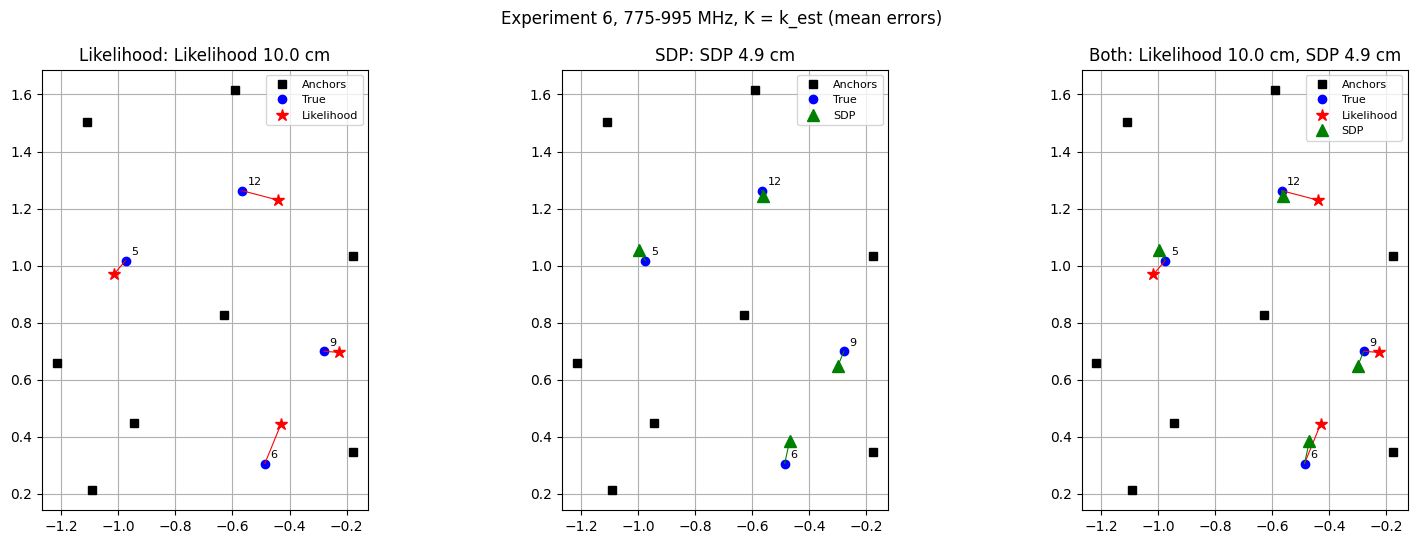

In [33]:
if sdp_est is not None:
    fig, axs = plt.subplots(1, 3, figsize=(16, 5.5))
    panels = [("Likelihood", [(est_m, "r*", "Likelihood")]), ("SDP", [(sdp_est, "g^", "SDP")]),
              ("Both", [(est_m, "r*", "Likelihood"), (sdp_est, "g^", "SDP")])]
    for ax, (title, series) in zip(axs, panels):
        ax.plot(*pts[anchors].T, "ks", label="Anchors")
        ax.plot(*pts[tags].T, "bo", label="True")
        for e, style, name in series:
            ax.plot(*e.T, style, ms=9, label=name)
            for a, b in zip(pts[tags], e):
                ax.plot([a[0], b[0]], [a[1], b[1]], style[0] + "-", lw=0.8)
        for t in tags:
            ax.annotate(str(t + 1), pts[t], textcoords="offset points", xytext=(4, 4), fontsize=8)
        means = {"Likelihood": err.mean(), "SDP": sdp_err.mean()}
        ax.set_title(f"{title}: " + ", ".join(f"{n} {means[n] * 100:.1f} cm" for _, _, n in series))
        ax.set_aspect("equal"); ax.grid(); ax.legend(fontsize=8)
    fig.suptitle(f"Experiment {EXP}, {BAND} MHz, K = {K_COL or 'ground truth'} (mean errors)")
    plt.tight_layout(); plt.show()